# Always run this import first

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anndata as ad
import seaborn as sns
import scanpy as sc
import os
import math

# Analysis of IHOPE26_LN InstanSeq Data (First time only)

Number of cells with area > 200: 77
Number of cells with area < 20:, 352


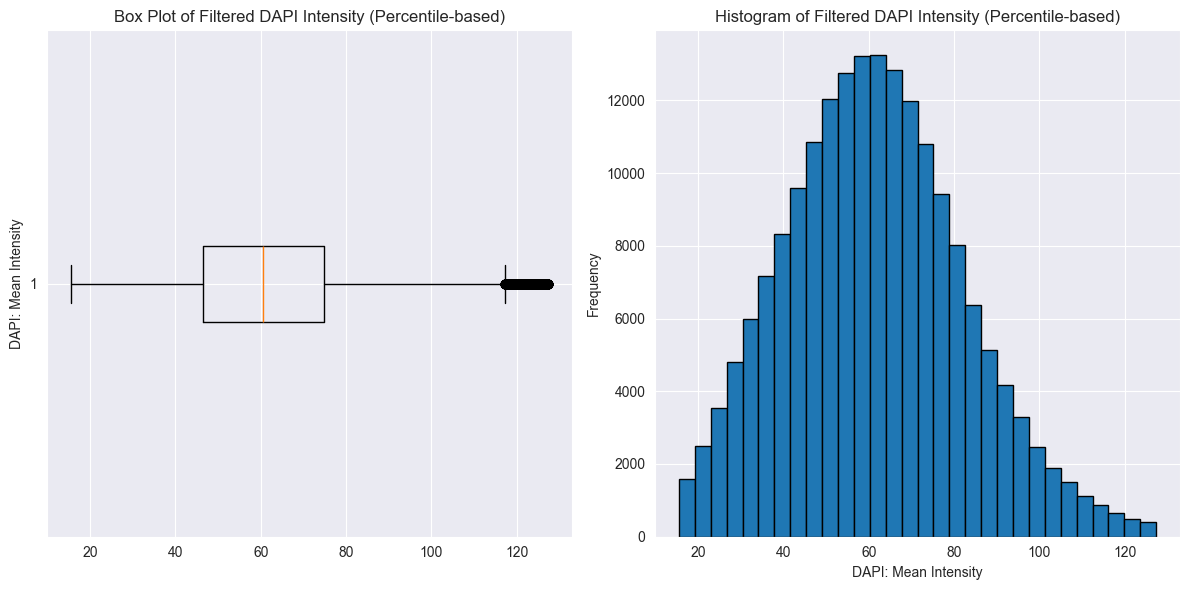

Number of outliers using percentile-based cutoff: 187097


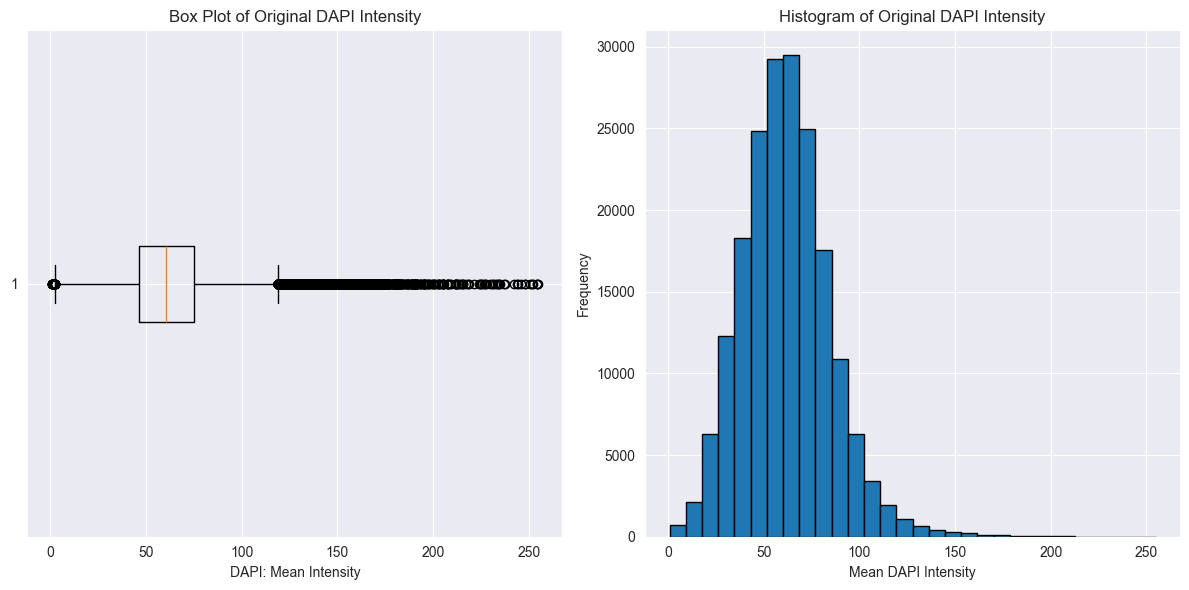

Filtered DataFrame with outliers has been exported to IHOPE26_LN_InstanSeq_filtered_outliers.csv


In [2]:
file_path = '../data/processed/IHOPE26_LN_InstanSeq_modified.csv'
df = pd.read_csv(file_path)

column_name = 'Area µm^2'

count_exceed = df[df[column_name] > 200].shape[0]
count_less_than = df[df[column_name] < 20].shape[0]

print(f"Number of cells with area > 200: {count_exceed}")
print(f"Number of cells with area < 20:, {count_less_than}")

# Filter the DataFrame to include only cells with area between 20 and 200
filtered_df = df[(df[column_name] >= 20) & (df[column_name] <=200)]



DAPI_intensity = "DAPI: Mean"

# Check if the column exists
if DAPI_intensity in df.columns:
    # Drop rows with NaN values in the specified column
    filtered_df = filtered_df.dropna(subset=[DAPI_intensity])

    # Calculate the 1st and 99th percentiles
    low_thresh = np.percentile(filtered_df[DAPI_intensity], 1)
    high_thresh = np.percentile(filtered_df[DAPI_intensity], 99)

    # Filter outliers based on the percentiles
    filtered_df = filtered_df[(filtered_df[DAPI_intensity] >= low_thresh) & (filtered_df[DAPI_intensity] <= high_thresh)]

    # Plot the filtered DAPI intensity
    plt.figure(figsize=(12, 6))
    # Box plot of the filtered data
    plt.subplot(1, 2, 1)
    plt.boxplot(filtered_df[DAPI_intensity], vert=False)
    plt.title('Box Plot of Filtered DAPI Intensity (Percentile-based)')
    plt.ylabel('DAPI: Mean Intensity')
    # Histogram of the filtered data
    plt.subplot(1, 2, 2)
    plt.hist(filtered_df[DAPI_intensity], bins=30, edgecolor='k')
    plt.title('Histogram of Filtered DAPI Intensity (Percentile-based)')
    plt.xlabel('DAPI: Mean Intensity')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

    print(f"Number of outliers using percentile-based cutoff: {filtered_df.shape[0]}")
else:
    print(f"Error: Column '{DAPI_intensity}' does not exist in the DataFrame.")


#Box plot of the original data
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.boxplot(df[DAPI_intensity], vert=False)
plt.title('Box Plot of Original DAPI Intensity')
plt.xlabel('DAPI: Mean Intensity')
# Histogram of the original data
plt.subplot(1, 2, 2)
plt.hist(df[DAPI_intensity], bins=30, edgecolor='k')
plt.title('Histogram of Original DAPI Intensity')
plt.xlabel('Mean DAPI Intensity')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


#Export the filtered DataFrame to a new CSV file
output_file_path = '../data/processed/IHOPE26_LN_InstanSeq_filtered_outliers.csv'
filtered_df.to_csv(output_file_path, index=False)
print(f"Filtered DataFrame with outliers has been exported to {output_file_path}")

# Arcsinh Transformation (First time only)

Successfully loaded data from IHOPE26_LN_InstanSeq_filtered_outliers.csv
DataFrame shape: (187097, 776)

Found 38 of the specified columns to transform.
Found 738 metadata columns.

--- Visualizing distributions BEFORE transformation ---


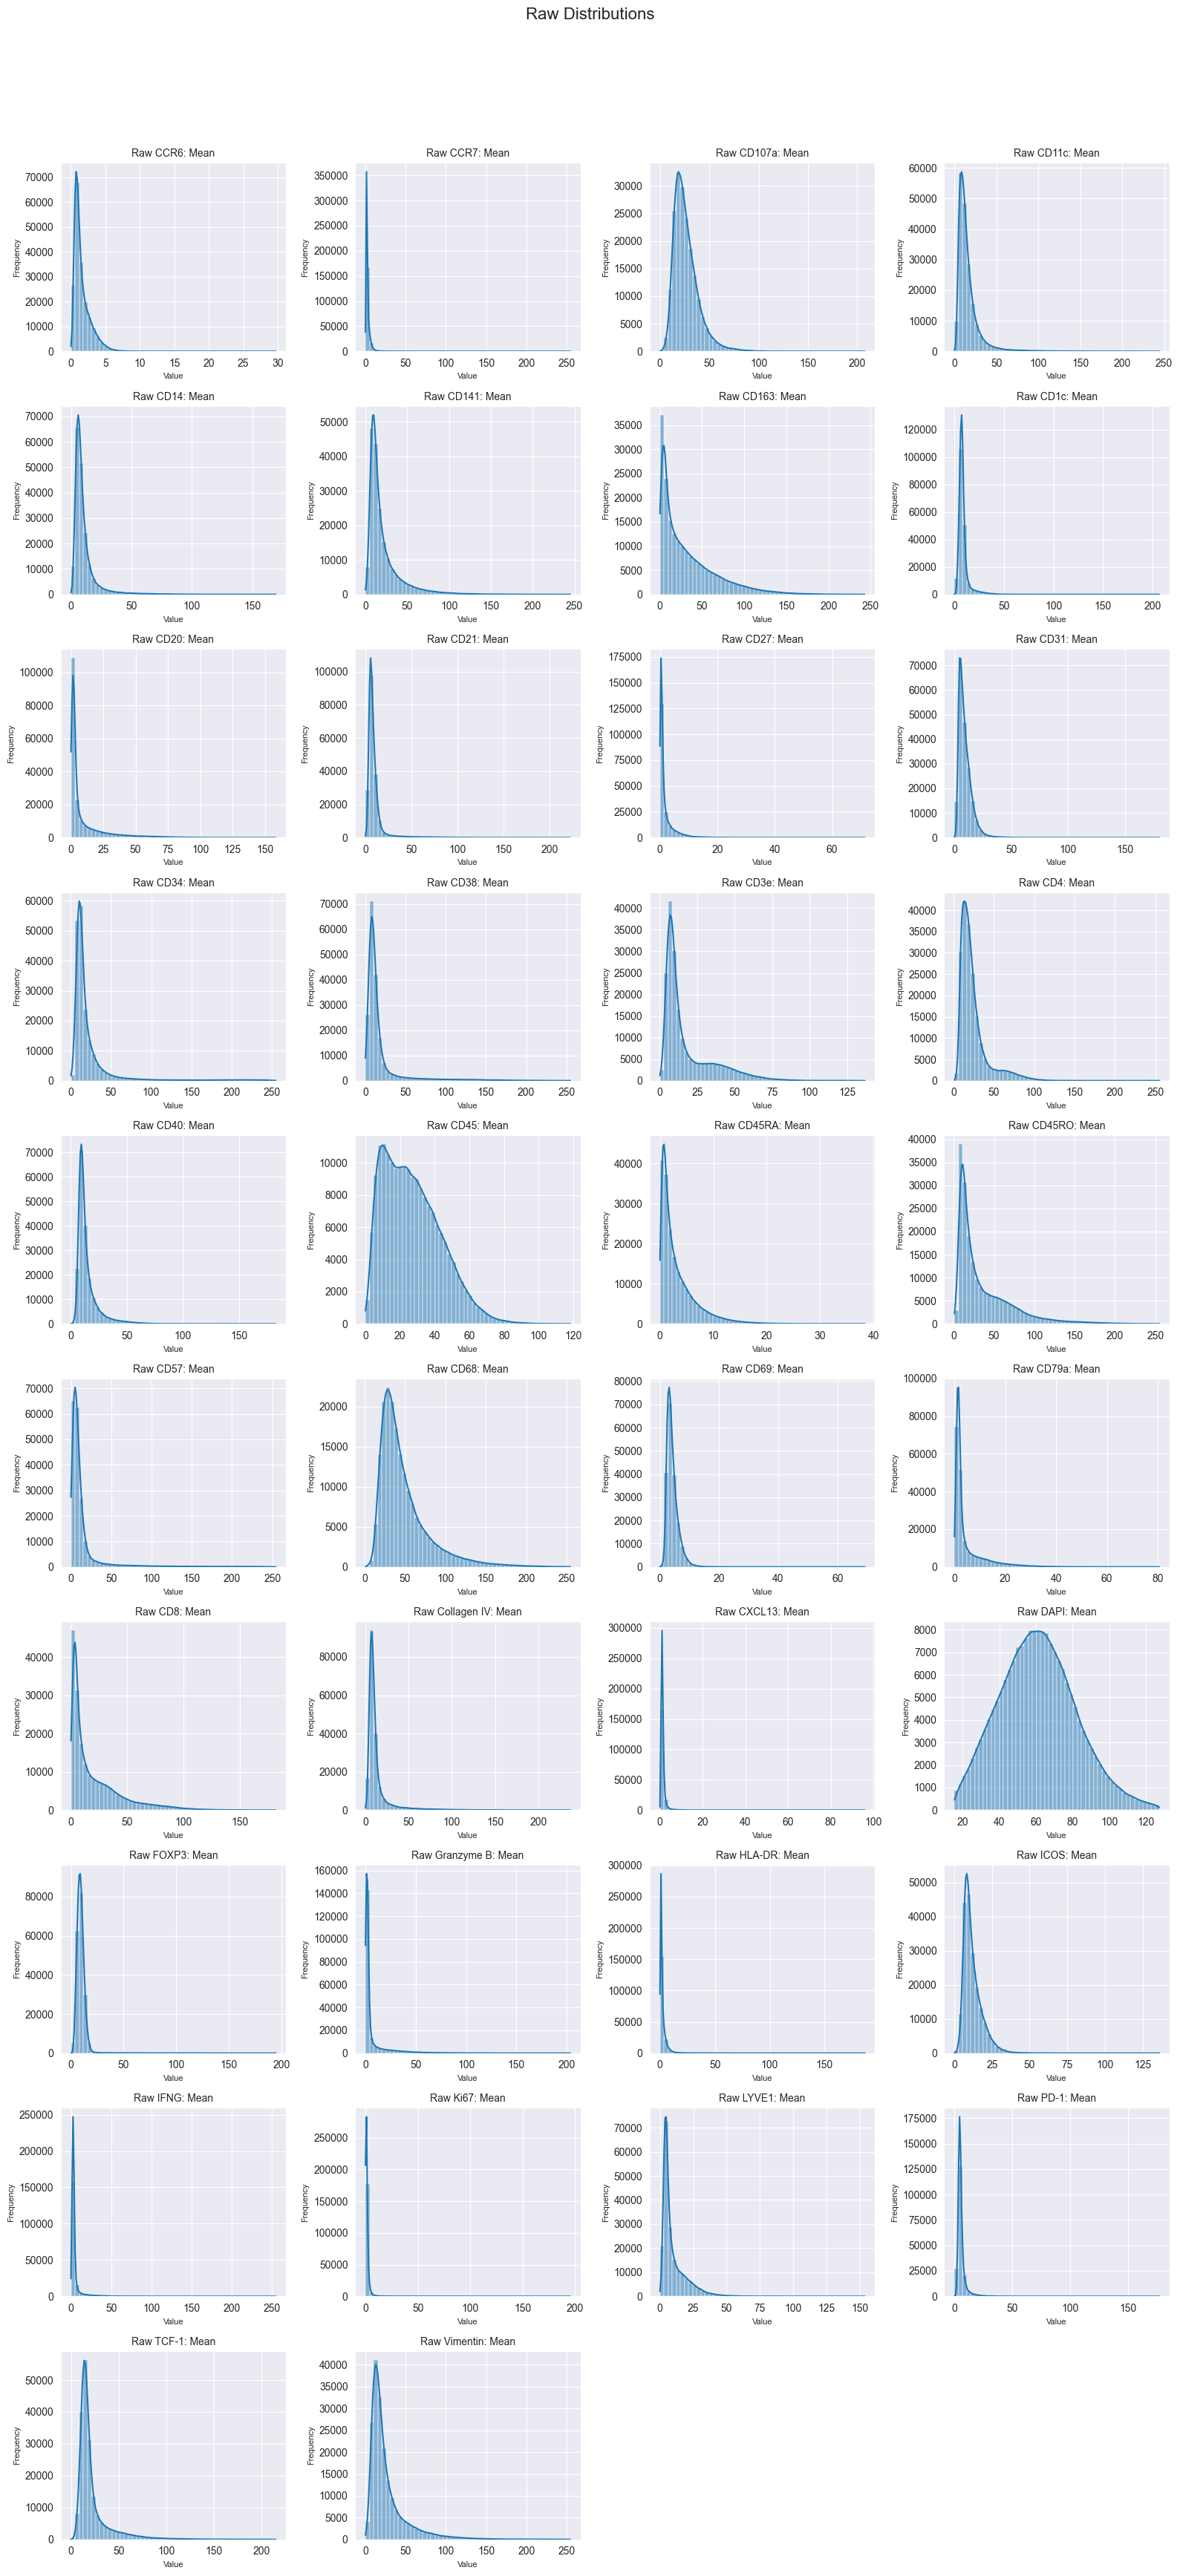


--- Applying Arcsinh transformation ---
Applied arcsinh transformation with a cofactor of 5.0.

--- Visualizing distributions AFTER Arcsinh transformation ---


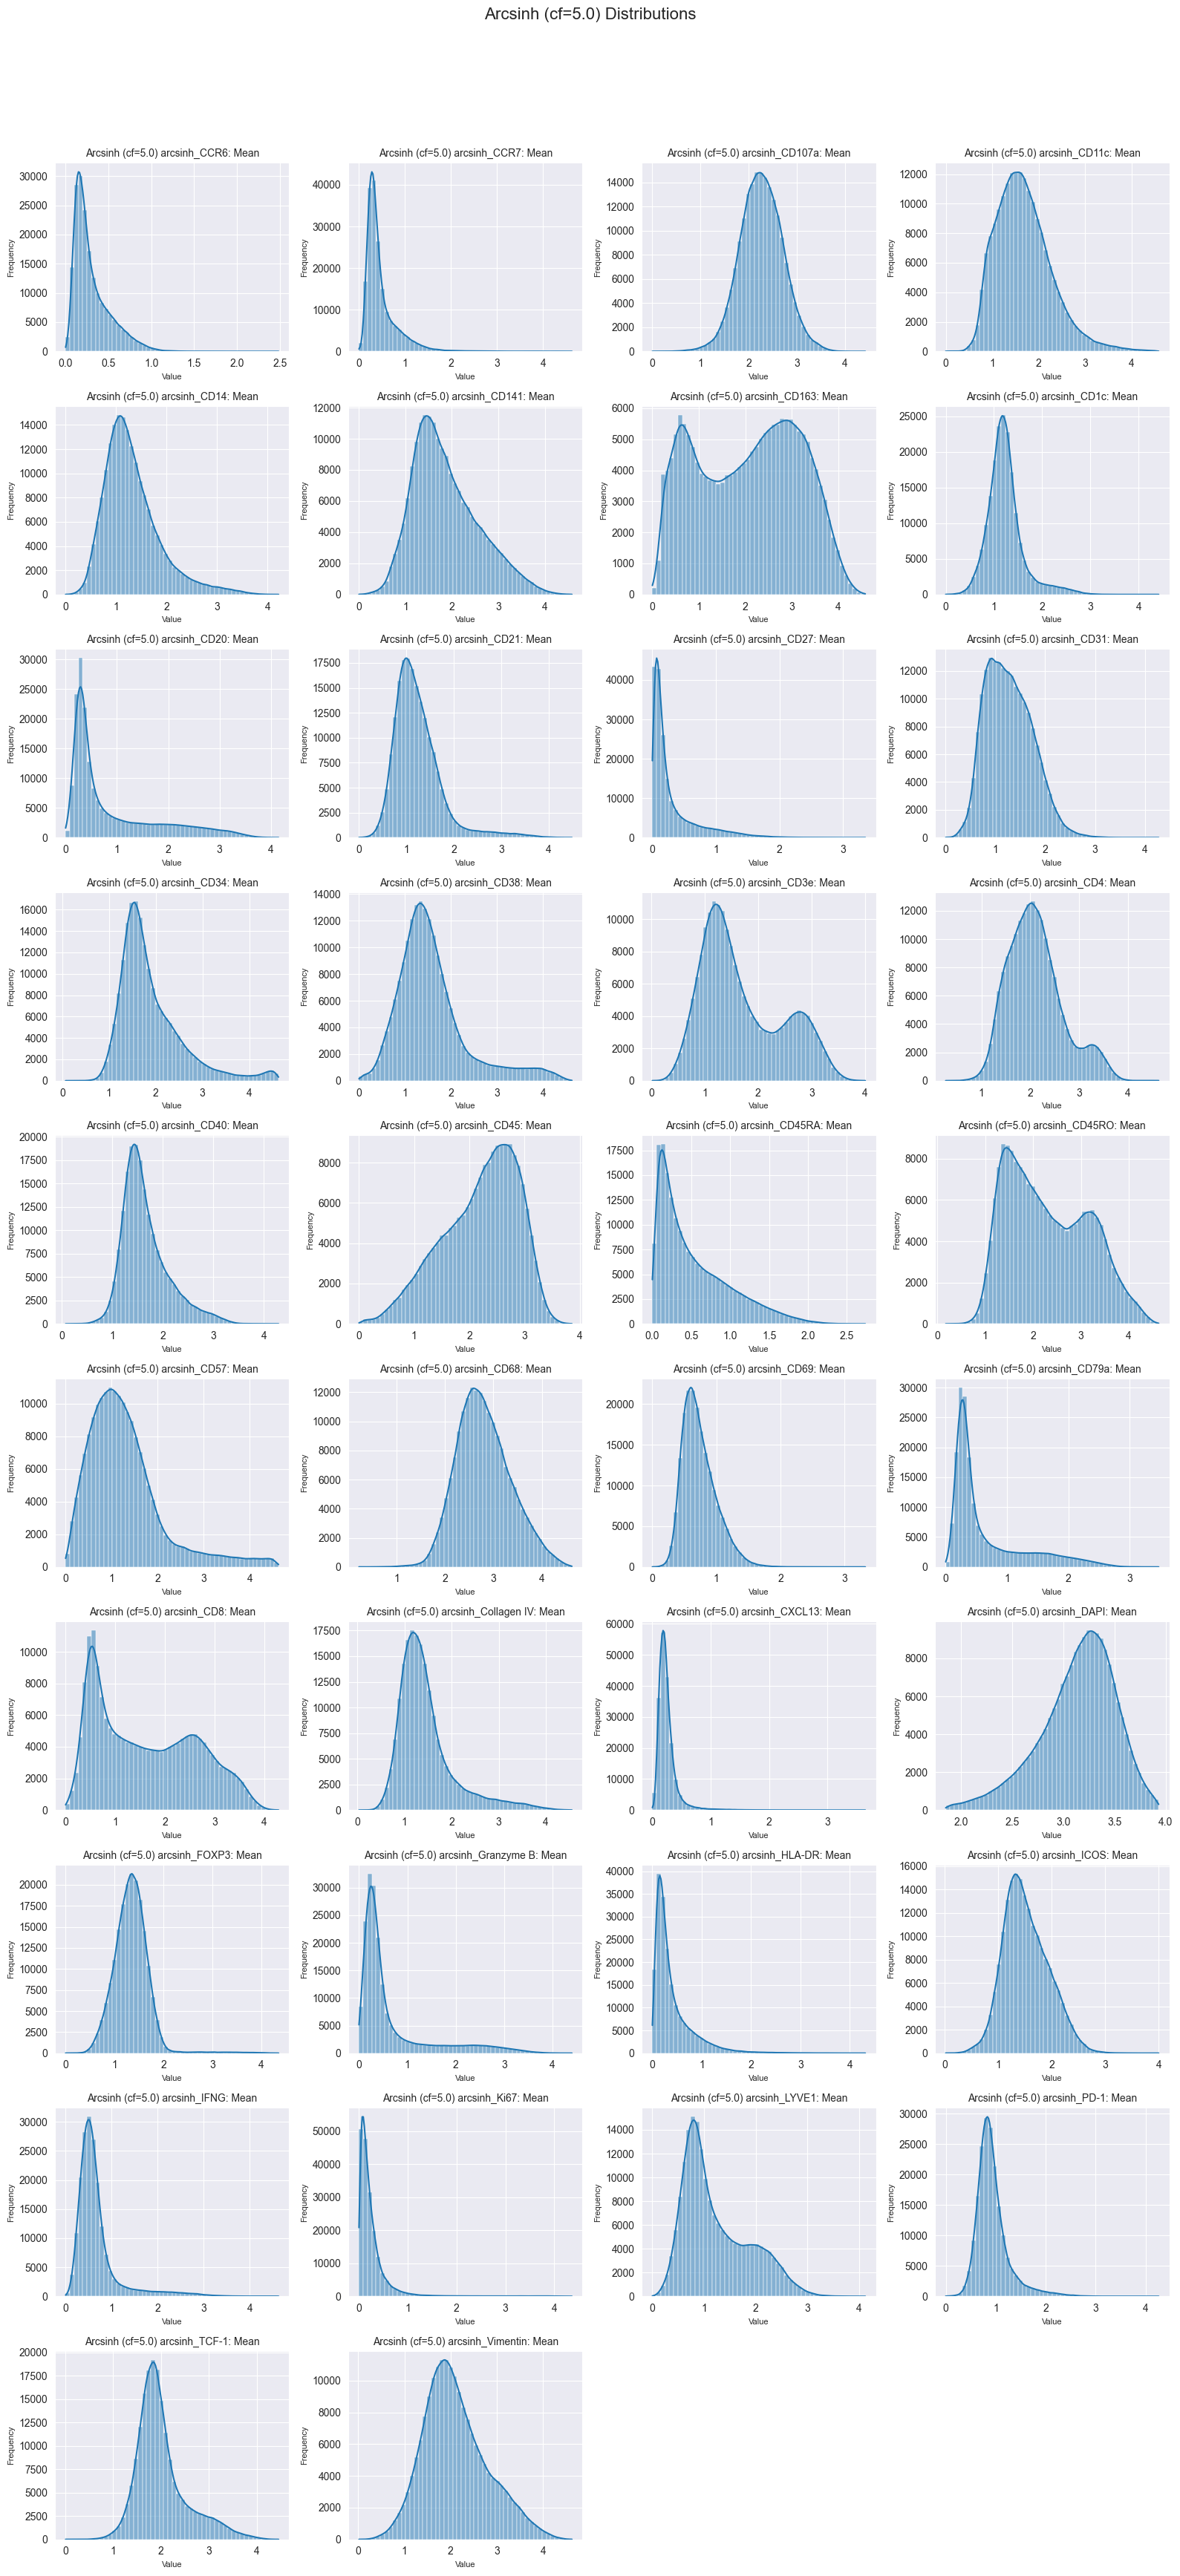


Saving transformed data to: IHOPE26_LN_InstanSeq_filtered_outliers_transformed2.csv
Export successful.

--- Example of final data (first 5 rows) ---
                              Object ID  Centroid X µm  Centroid Y µm  \
0  71e5c938-d604-4de5-8f9c-c887b780f1a6         5138.8        15305.5   
1  e1cb8a7d-1961-468b-92f4-1cffba1743ab         5136.4        15344.9   
2  0cf0286e-5965-43ac-a9e3-40ae50ebe3a0         5123.6        15350.8   
3  b9d99d0a-7585-4cf4-90ad-c66b453fb831         5132.0        15353.4   
4  f29cd6b9-3819-4c96-82de-2120174d2780         5114.6        15354.7   

   Area µm^2  Length µm  Circularity  Solidity  Max diameter µm  \
0   115.6042    49.2773       0.5983    0.9491          13.9796   
1    55.4990    34.9961       0.5695    0.9250           9.7924   
2    50.4885    38.0049       0.4393    0.8876          12.7470   
3   135.2636    59.9922       0.4723    0.8799          16.6539   
4    47.5049    31.9971       0.5831    0.9313           9.7509   

   Min d

In [11]:
# Load Data
file_path = '../data/processed/IHOPE26_LN_InstanSeq_filtered_outliers.csv'
try:
    df = pd.read_csv(file_path)
    print(f"Successfully loaded data from {file_path}")
    print(f"DataFrame shape: {df.shape}")
except FileNotFoundError:
    print(f"Error: File not found at {file_path}")
    exit()
except Exception as e:
    print(f"Error loading CSV: {e}")
    exit()

# Columns for Transformation
# Define the specific list of columns to be transformed
target_columns = [
    "CCR6: Mean", "CCR7: Mean", "CD107a: Mean", "CD11c: Mean", "CD14: Mean", "CD141: Mean",
    "CD163: Mean", "CD1c: Mean", "CD20: Mean", "CD21: Mean", "CD27: Mean", "CD31: Mean",
    "CD34: Mean", "CD38: Mean", "CD3e: Mean", "CD4: Mean", "CD40: Mean", "CD45: Mean",
    "CD45RA: Mean", "CD45RO: Mean", "CD57: Mean", "CD68: Mean", "CD69: Mean", "CD79a: Mean",
    "CD8: Mean", "Collagen IV: Mean", "CXCL13: Mean", "DAPI: Mean", "FOXP3: Mean",
    "Granzyme B: Mean", "HLA-DR: Mean", "ICOS: Mean", "IFNG: Mean", "Ki67: Mean", "LYVE1: Mean",
    "PD-1: Mean", "TCF-1: Mean", "Vimentin: Mean"
]

# Validate that the target columns exist in the DataFrame to prevent errors
columns_to_transform = [col for col in target_columns if col in df.columns]
missing_columns = set(target_columns) - set(columns_to_transform)

if not columns_to_transform:
    print("Error: None of the specified target columns were found in the DataFrame.")
    exit()
if missing_columns:
    print(f"Warning: The following specified columns were not found and will be skipped:")
    print(f"   {', '.join(missing_columns)}")

# Identify metadata columns (all columns that are not being transformed)
metadata_columns = [col for col in df.columns if col not in columns_to_transform]

print(f"\nFound {len(columns_to_transform)} of the specified columns to transform.")
print(f"Found {len(metadata_columns)} metadata columns.")


# Function for Visualization
def plot_distributions(data_frame, columns, title_prefix="", bins=50):
    """Visualizes the distribution of specified columns in a DataFrame."""
    if not columns:
        print(f"No columns to plot for prefix '{title_prefix}'. Skipping.")
        return
    
    n_cols_plot = 4
    n_rows_plot = math.ceil(len(columns) / n_cols_plot)
    fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(n_cols_plot * 4, n_rows_plot * 3.5), squeeze=False)
    axes = axes.flatten()

    for i, col in enumerate(columns):
        if col in data_frame.columns:
            sns.histplot(data=data_frame, x=col, bins=bins, kde=True, ax=axes[i])
            axes[i].set_title(f"{title_prefix}{col}", fontsize=10)
            axes[i].set_xlabel("Value", fontsize=8)
            axes[i].set_ylabel("Frequency", fontsize=8)
    
    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
        
    fig.suptitle(f"{title_prefix}Distributions", fontsize=16, y=1.02)
    plt.tight_layout(rect=[0, 0.03, 1, 0.98])
    plt.show()

# Visualize Original Data
print("\n--- Visualizing distributions BEFORE transformation ---")
plot_distributions(df, columns_to_transform, title_prefix="Raw ")

# Apply Arcsinh Transformation
print("\n--- Applying Arcsinh transformation ---")

cofactor = 5.0 
transformed_column_names = []
for col in columns_to_transform:
    new_col_name = f"arcsinh_{col}"
    df[new_col_name] = np.arcsinh(df[col] / cofactor)
    transformed_column_names.append(new_col_name)

print(f"Applied arcsinh transformation with a cofactor of {cofactor}.")

# Visualize Transformed Data
print("\n--- Visualizing distributions AFTER Arcsinh transformation ---")
plot_distributions(df, transformed_column_names, title_prefix=f"Arcsinh (cf={cofactor}) ")

# Save Final DataFrame
# Combine metadata and the newly transformed columns
final_columns = metadata_columns + transformed_column_names
df_to_export = df[final_columns]

# Define output file path
output_file = 'IHOPE26_LN_InstanSeq_filtered_outliers_transformed2.csv'

print(f"\nSaving transformed data to: {output_file}")
try:
    df_to_export.to_csv(output_file, index=False)
    print("Export successful.")
    print("\n--- Example of final data (first 5 rows) ---")
    print(df_to_export.head())
except Exception as e:
    print(f"Error saving file: {e}")

print("\nProcess complete.")

# Log Z normalization

Successfully loaded data from IHOPE26_LN_InstanSeq_filtered_outliers.csv
DataFrame shape: (187097, 776)

Found 38 of the specified columns to transform.
Found 738 metadata columns.

--- Visualizing distributions BEFORE transformation ---


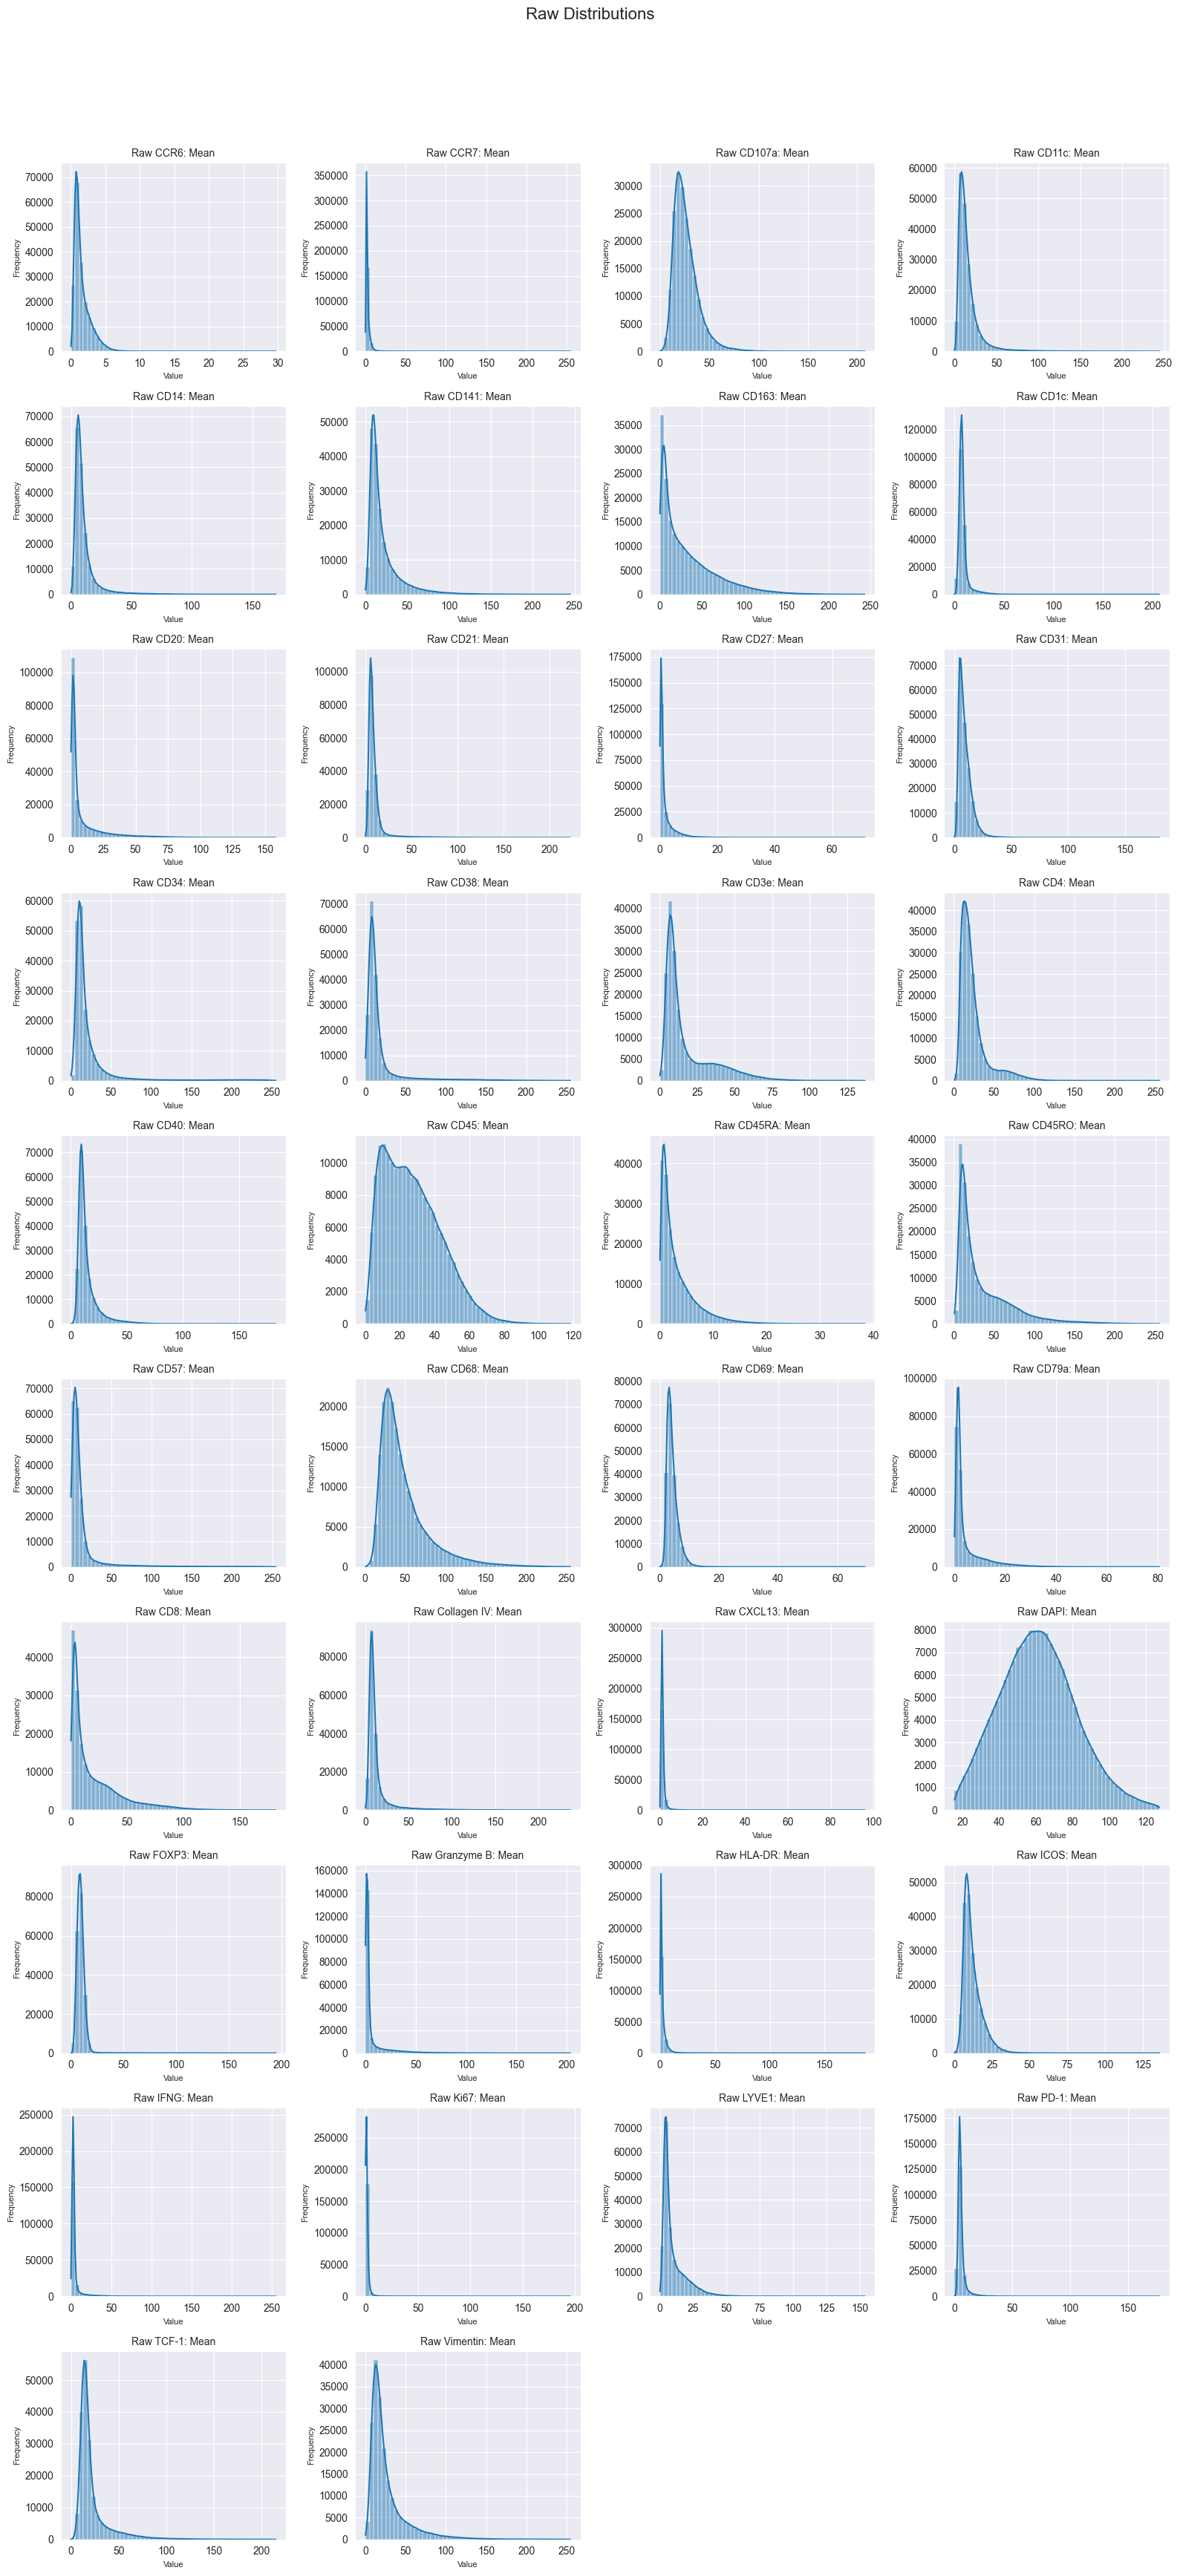


--- Applying Z-score normalization ---
Applied Z-score normalization.

--- Visualizing distributions AFTER Z-score normalization ---


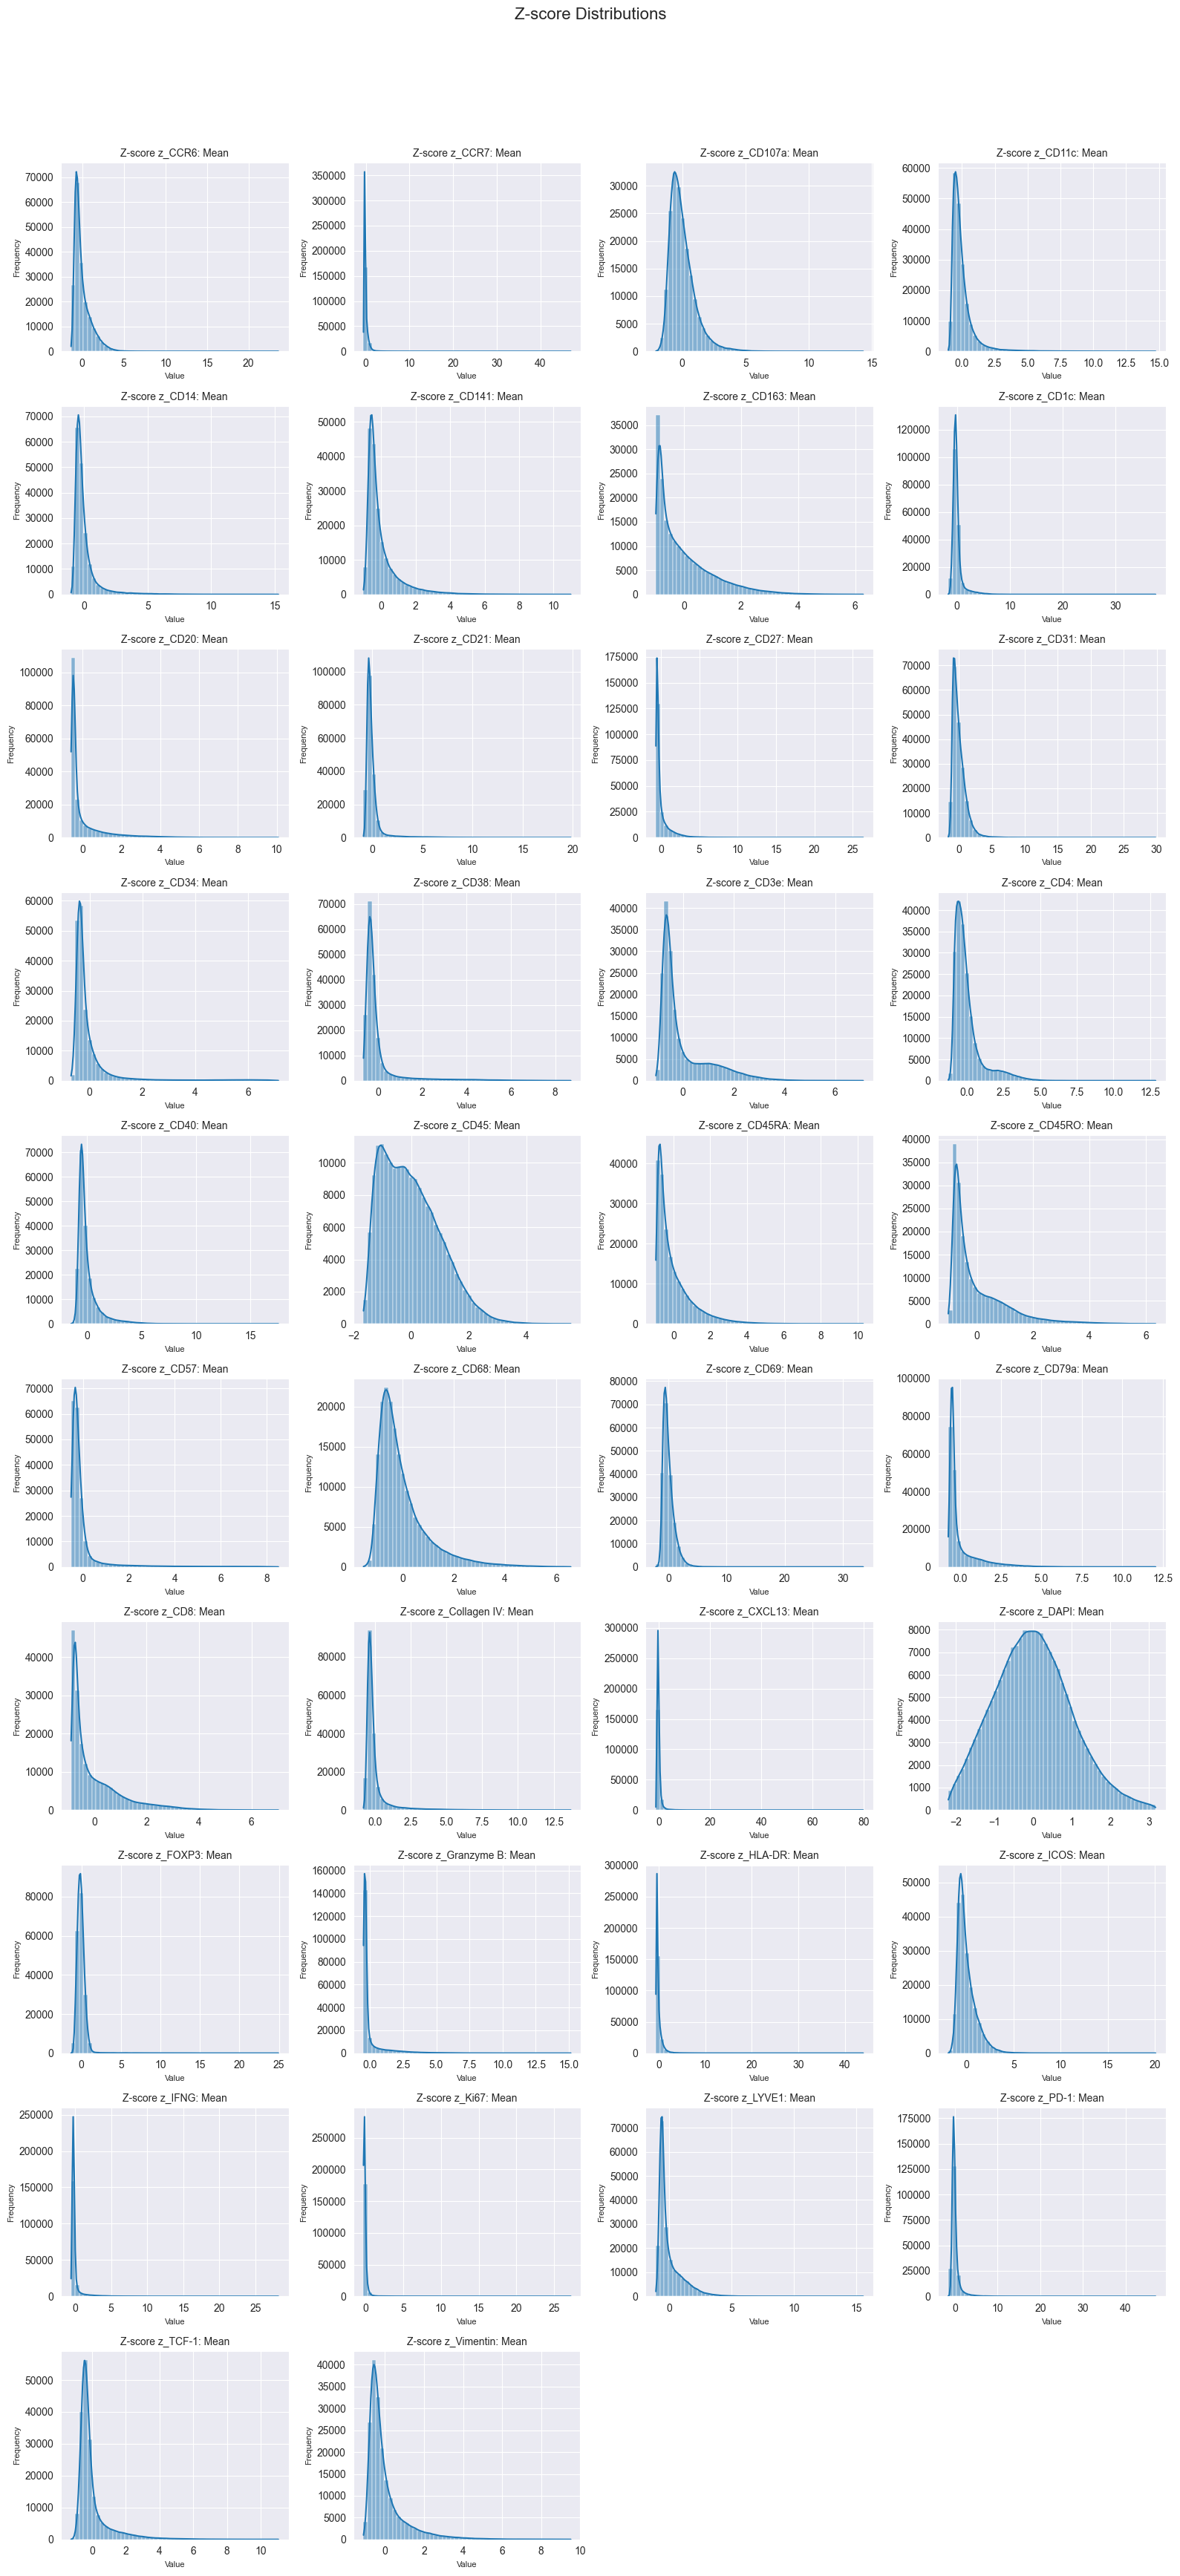


Saving normalized data to: IHOPE26_LN_InstanSeq_filtered_outliers_zscore.csv
Export complete.


In [38]:
from scipy.stats import zscore

# Load Data
file_path = '../data/processed/IHOPE26_LN_InstanSeq_filtered_outliers.csv'
try:
    df = pd.read_csv(file_path)
    print(f"Successfully loaded data from {file_path}")
    print(f"DataFrame shape: {df.shape}")
except FileNotFoundError:
    print(f"Error: File not found at {file_path}")
    exit()
except Exception as e:
    print(f"Error loading CSV: {e}")
    exit()

# Columns for Transformation
# Define the specific list of columns to be transformed
target_columns = [
    "CCR6: Mean", "CCR7: Mean", "CD107a: Mean", "CD11c: Mean", "CD14: Mean", "CD141: Mean",
    "CD163: Mean", "CD1c: Mean", "CD20: Mean", "CD21: Mean", "CD27: Mean", "CD31: Mean",
    "CD34: Mean", "CD38: Mean", "CD3e: Mean", "CD4: Mean", "CD40: Mean", "CD45: Mean",
    "CD45RA: Mean", "CD45RO: Mean", "CD57: Mean", "CD68: Mean", "CD69: Mean", "CD79a: Mean",
    "CD8: Mean", "Collagen IV: Mean", "CXCL13: Mean", "DAPI: Mean", "FOXP3: Mean",
    "Granzyme B: Mean", "HLA-DR: Mean", "ICOS: Mean", "IFNG: Mean", "Ki67: Mean", "LYVE1: Mean",
    "PD-1: Mean", "TCF-1: Mean", "Vimentin: Mean"
]

# Validate that the target columns exist in the DataFrame to prevent errors
columns_to_transform = [col for col in target_columns if col in df.columns]
missing_columns = set(target_columns) - set(columns_to_transform)

if not columns_to_transform:
    print("Error: None of the specified target columns were found in the DataFrame.")
    exit()
if missing_columns:
    print(f"Warning: The following specified columns were not found and will be skipped:")
    print(f"   {', '.join(missing_columns)}")

# Identify metadata columns (all columns that are not being transformed)
metadata_columns = [col for col in df.columns if col not in columns_to_transform]

print(f"\nFound {len(columns_to_transform)} of the specified columns to transform.")
print(f"Found {len(metadata_columns)} metadata columns.")

# Function for Visualization
def plot_distributions(data_frame, columns, title_prefix="", bins=50):
    """Visualizes the distribution of specified columns in a DataFrame."""
    if not columns:
        print(f"No columns to plot for prefix '{title_prefix}'. Skipping.")
        return

    n_cols_plot = 4
    n_rows_plot = math.ceil(len(columns) / n_cols_plot)
    fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(n_cols_plot * 4, n_rows_plot * 3.5), squeeze=False)
    axes = axes.flatten()

    for i, col in enumerate(columns):
        if col in data_frame.columns:
            sns.histplot(data=data_frame, x=col, bins=bins, kde=True, ax=axes[i])
            axes[i].set_title(f"{title_prefix}{col}", fontsize=10)
            axes[i].set_xlabel("Value", fontsize=8)
            axes[i].set_ylabel("Frequency", fontsize=8)

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(f"{title_prefix}Distributions", fontsize=16, y=1.02)
    plt.tight_layout(rect=[0, 0.03, 1, 0.98])
    plt.show()

# Visualize Original Data
print("\n--- Visualizing distributions BEFORE transformation ---")
plot_distributions(df, columns_to_transform, title_prefix="Raw ")

# Apply Z-score Normalization
print("\n--- Applying Z-score normalization ---")

transformed_column_names = []

for col in columns_to_transform:
    new_col_name = f"z_{col}"
    df[new_col_name] = zscore(df[col])
    transformed_column_names.append(new_col_name)

print("Applied Z-score normalization.")

# Visualize Transformed Data
print("\n--- Visualizing distributions AFTER Z-score normalization ---")
plot_distributions(df, transformed_column_names, title_prefix="Z-score ")

# Save Final DataFrame
final_columns = metadata_columns + transformed_column_names
df_to_export = df[final_columns]

output_file = '../data/processed/IHOPE26_LN_InstanSeq_filtered_outliers_zscore.csv'
print(f"\nSaving normalized data to: {output_file}")
df_to_export.to_csv(output_file, index=False)
print("Export complete.")



# Creating anndata object from the dataset ( NEW SESSION HERE)

In [15]:
#Loading dataset into anndata

file_path = '../data/processed/IHOPE26_LN_InstanSeq_filtered_outliers_transformed.csv'
df = pd.read_csv(file_path)

intensity_columns = [col for col in df.columns if 'arcsinh_' in col and col.endswith(': Mean')]
obs_cols = ['Object ID', 'Centroid X µm', 'Centroid Y µm', 'Area µm^2', 'Nucleus/Cell area ratio']


# Check for missing columns
missing_intensities_columns = [col for col in intensity_columns if col not in df.columns]
missing_obs_columns = [col for col in obs_cols if col not in df.columns]

if missing_intensities_columns or missing_obs_columns:
    raise ValueError(f"Missing columns: {missing_intensities_columns} , {missing_obs_columns}")

# Check for invalid values in intensity columns
if not np.all(np.isfinite(df[intensity_columns].values)):
    raise ValueError("Invalid values (NaN, Inf, or -Inf) detected in intensity columns.")

# Check for invalid values in observation columns (numeric only)
numeric_obs_cols = df[obs_cols].select_dtypes(include=[np.number])
if not np.all(np.isfinite(numeric_obs_cols.values)):
    raise ValueError("Invalid values (NaN, Inf, or -Inf) detected in numeric observation columns.")

# Drop any remaining rows with NaN values in any of the specified columns
df = df.dropna(subset=intensity_columns + obs_cols)

# Create X matrix (biomarker intensities)
X = df[intensity_columns].values

# Create obs DataFrame (Cell annotations)
obs = df[obs_cols]

# Create var DataFrame (Biomarker names)
var = pd.DataFrame(index=[col.replace('arcsinh_', '').replace(': Mean', '') for col in intensity_columns])

# Create anndata object
adata = ad.AnnData(X=X, obs=obs, var=var)

# Set the index of the obs DataFrame to 'Object ID'
adata.obs_names = df['Object ID'].astype(str)

adata.obsm['spatial'] = adata.obs[['Centroid X µm', 'Centroid Y µm']].values

# Set the index of the var DataFrame to the cleaned column names
adata.var_names = [col.replace('arcsinh_', '').replace(': Mean', '') for col in intensity_columns]

print(df.dtypes)
print(adata.obsm['spatial'].shape)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/functools.py:931: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


Object ID                  object
Centroid X µm             float64
Centroid Y µm             float64
Area µm^2                 float64
Length µm                 float64
                           ...   
arcsinh_Ki67: Mean        float64
arcsinh_LYVE1: Mean       float64
arcsinh_PD-1: Mean        float64
arcsinh_TCF-1: Mean       float64
arcsinh_Vimentin: Mean    float64
Length: 776, dtype: object
(187097, 2)


In [16]:

print(adata.obs.columns)


Index(['Object ID', 'Centroid X µm', 'Centroid Y µm', 'Area µm^2',
       'Nucleus/Cell area ratio'],
      dtype='object')


In [21]:
print(adata.var)

Empty DataFrame
Columns: []
Index: [CCR6, CCR7, CD107a, CD11c, CD14, CD141, CD163, CD1c, CD20, CD21, CD27, CD31, CD34, CD38, CD3e, CD4, CD40, CD45, CD45RA, CD45RO, CD57, CD68, CD69, CD79a, CD8, Collagen IV, CXCL13, DAPI, FOXP3, Granzyme B, HLA-DR, ICOS, IFNG, Ki67, LYVE1, PD-1, TCF-1, Vimentin]


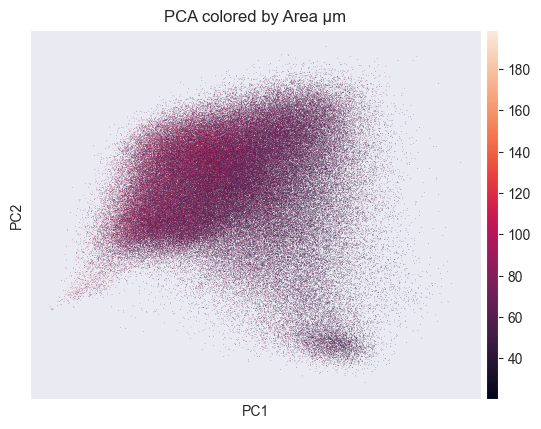

/var/folders/30/65bd79gx1xq3x7x5jng74jrh0000gn/T/ipykernel_46017/3611015306.py:9: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.5)


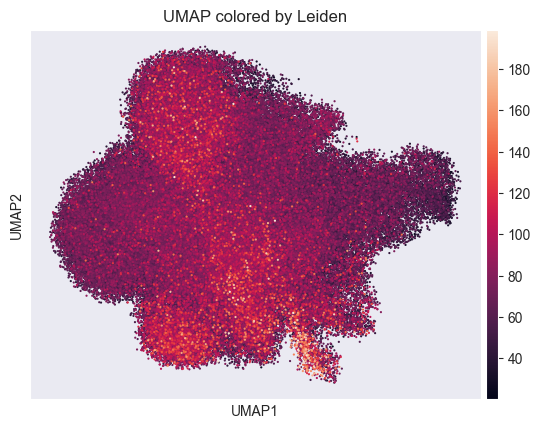

In [6]:
sc.tl.pca(adata)

sc.pl.pca(adata, color='Area µm^2', title='PCA colored by Area µm')

sc.pp.neighbors(adata, n_neighbors=10, use_rep='X_pca')

sc.tl.umap(adata, min_dist=0.5, spread=0.3)

sc.tl.leiden(adata, resolution=0.5)

sc.pl.umap(adata, color='Area µm^2', title='UMAP colored by area', size=10)

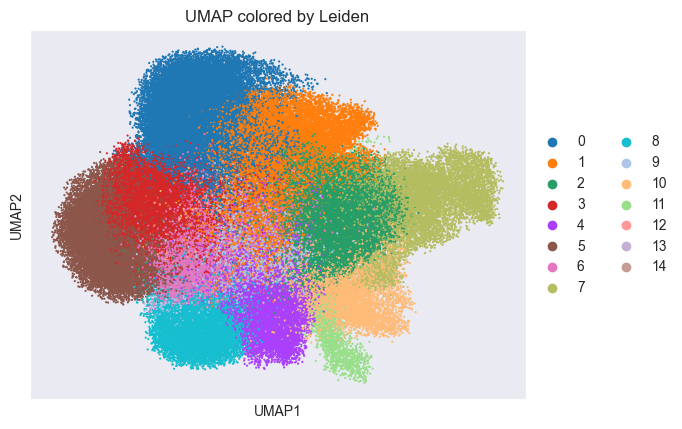

In [7]:
sc.pl.umap(adata, color='leiden', title='UMAP colored by Leiden', size=10)


# INSPECTING THE PC:S

In [ ]:
import scipy.stats as stats

In [8]:
# Compute correlation between each marker and each PC
pc_scores = adata.obsm['X_pca']  # shape (n_cells, n_pcs)
loadings = np.corrcoef(adata.X.T, pc_scores.T)[:adata.X.shape[1], adata.X.shape[1]:]

# Convert to DataFrame
pc_loadings_df = pd.DataFrame(loadings, index=adata.var_names,
                              columns=[f'PC{i+1}' for i in range(pc_scores.shape[1])])

# Sort markers by absolute contribution to PC1
pc1_top = pc_loadings_df['PC1'].abs().sort_values(ascending=False)
print("Top markers contributing to PC1:")
print(pc1_top.head(10))

Top markers contributing to PC1:
CD45      0.888881
ICOS      0.766690
CD45RA    0.749187
CD3e      0.684188
CD57      0.671648
FOXP3     0.654676
PD-1      0.637496
CD1c      0.621494
DAPI      0.601088
CD40      0.601025
Name: PC1, dtype: float64


# GENERATING AN IMPROVED HEATMAP WITH CSV EXPORT

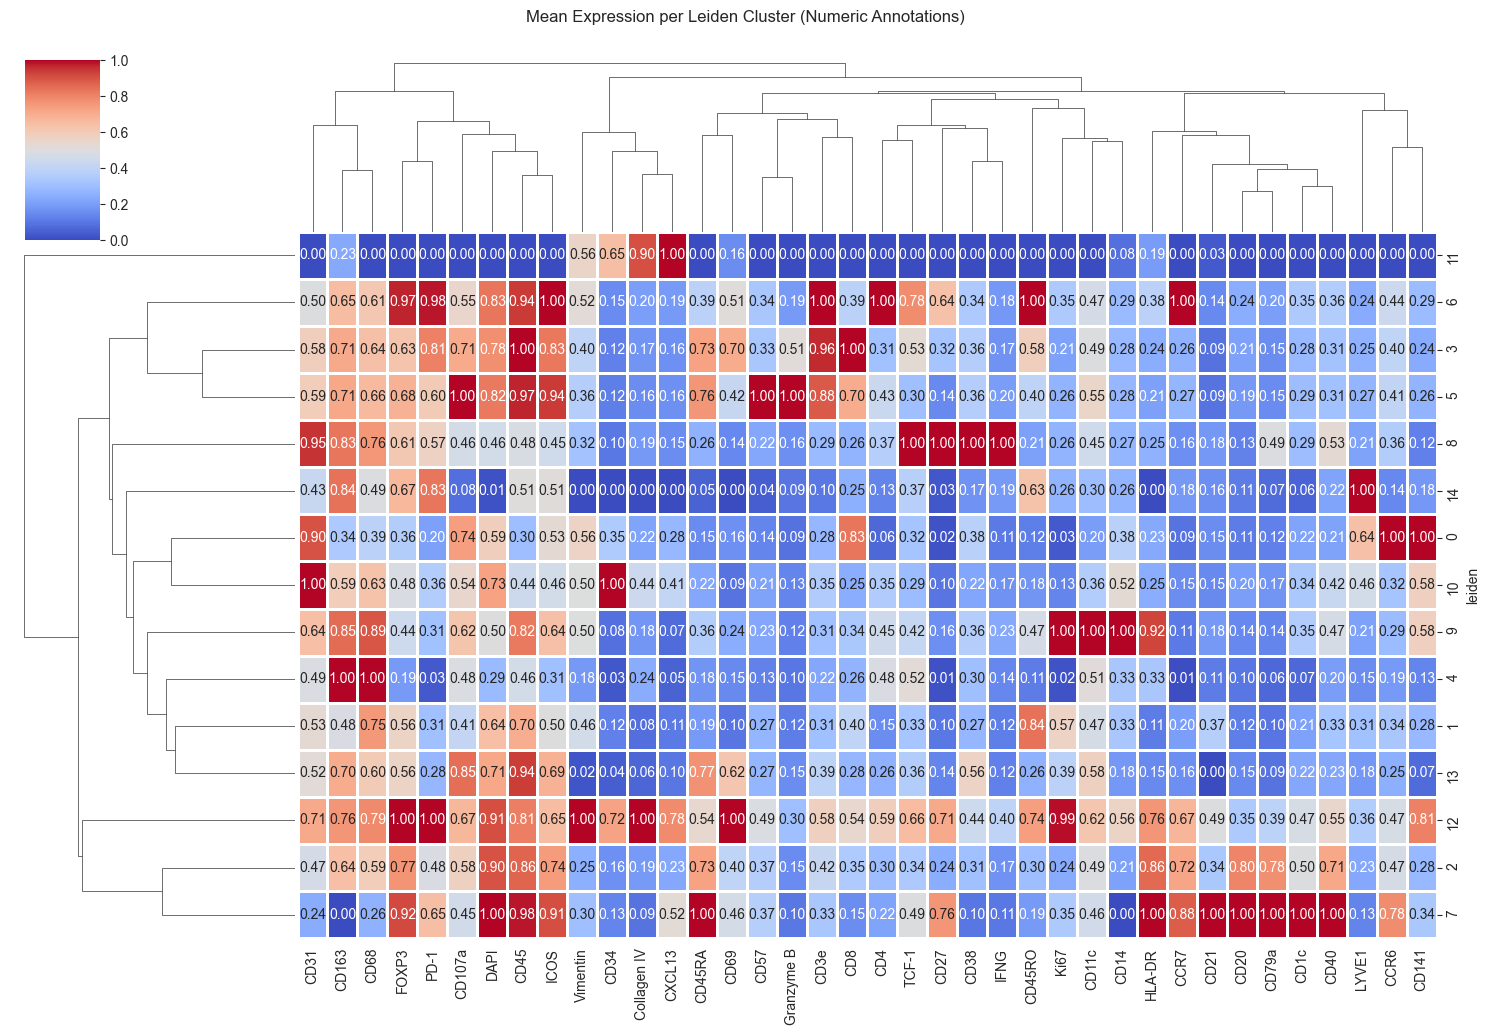


--- Numerical Data from Heatmap ---
The following table shows the scaled and clustered data as seen in the heatmap:
            CD31     CD163      CD68     FOXP3      PD-1    CD107a      DAPI  \
leiden                                                                         
11      0.000000  0.233316  0.000000  0.000000  0.000000  0.000000  0.000000   
6       0.495022  0.650691  0.613925  0.969271  0.984317  0.550019  0.829311   
3       0.584938  0.710908  0.637702  0.627649  0.805405  0.706854  0.775221   
5       0.592716  0.713893  0.657128  0.684782  0.598636  1.000000  0.822268   
8       0.950122  0.831130  0.757131  0.610028  0.566957  0.462923  0.457393   
14      0.425091  0.837366  0.491866  0.665288  0.830606  0.079724  0.013891   
0       0.901846  0.340304  0.385422  0.361415  0.204814  0.735626  0.585130   
10      1.000000  0.591578  0.631848  0.480699  0.358715  0.543058  0.728037   
9       0.643397  0.848150  0.892390  0.442033  0.309507  0.623824  0.500653   
4  

In [10]:
# Recompute per-cluster means from the updated `adata`
if 'leiden' not in adata.obs:
    raise ValueError("Missing 'leiden' in adata.obs. Re-run clustering before plotting.")

# Ensure string labels and build expression DataFrame
adata.obs['leiden'] = adata.obs['leiden'].astype(str)
expr_df = pd.DataFrame(np.asarray(adata.X), columns=adata.var_names, index=adata.obs_names)
expr_df['leiden'] = adata.obs['leiden'].values

# Mean expression per cluster
scaled_means_df = expr_df.groupby('leiden').mean()

# Optional: sort clusters numerically if labels are numeric strings
try:
    scaled_means_df = scaled_means_df.sort_index(key=lambda x: pd.to_numeric(x))
except Exception:
    pass

# Re-plot the heatmap with numeric annotations
clustergrid = sns.clustermap(
    scaled_means_df,
    cmap='coolwarm',
    linewidths=0.75,
    standard_scale=1,   # scale each row (cluster) for visualization
    figsize=(15, 10), # Use capped figure size
    annot=True,
    fmt=".2f",
    dendrogram_ratio=(0.2, 0.2)
)
clustergrid.fig.suptitle('Mean Expression per Leiden Cluster (Numeric Annotations)', y=1.03)
plt.setp(clustergrid.ax_heatmap.get_xticklabels(), rotation=90)
plt.show()

# --- Extract and display the numerical data from the heatmap ---
print("\n--- Numerical Data from Heatmap ---")
# The clustermap reorders the rows and columns. We can get this new order.
reordered_row_indices = clustergrid.dendrogram_row.reordered_ind
reordered_col_indices = clustergrid.dendrogram_col.reordered_ind

# Get the reordered labels from the original DataFrame
reordered_rows = scaled_means_df.index[reordered_row_indices]
reordered_cols = scaled_means_df.columns[reordered_col_indices]

# The `data2d` attribute holds the scaled and reordered numerical data
heatmap_data = clustergrid.data2d

# Create a new DataFrame with the reordered data and labels
reordered_df = pd.DataFrame(heatmap_data, index=reordered_rows, columns=reordered_cols)

print("The following table shows the scaled and clustered data as seen in the heatmap:")
print(reordered_df)

# --- NEW: Export the numerical data to a CSV file ---
output_csv_path = '../data/processed/IHOPE26_LN_heatmap_numerical_data.csv'
reordered_df.to_csv(output_csv_path)
print(f"\nNumerical data from the heatmap has been exported to '{output_csv_path}'")

In [11]:
# Get and display cell counts per cluster
print("\n--- Cell Counts per Cluster ---")
# Use value_counts() to get the number of cells in each cluster
# Sort by index
cluster_counts = adata.obs['leiden'].value_counts().sort_index(key=lambda x: pd.to_numeric(x, errors='ignore'))
print("The following table shows the number of cells in each cluster:")
print(cluster_counts.to_string())


--- Cell Counts per Cluster ---
The following table shows the number of cells in each cluster:
leiden
0     29708
1     29101
2     22555
3     19405
4     16991
5     15454
6     14583
7      9987
8      9622
9      8613
10     7403
11     1676
12     1561
13      415
14       23


/var/folders/30/65bd79gx1xq3x7x5jng74jrh0000gn/T/ipykernel_42226/2971441731.py:5: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  cluster_counts = adata.obs['leiden'].value_counts().sort_index(key=lambda x: pd.to_numeric(x, errors='ignore'))



--- Plotting spatial distribution of clusters ---


/var/folders/30/65bd79gx1xq3x7x5jng74jrh0000gn/T/ipykernel_42226/2232884734.py:9: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata,


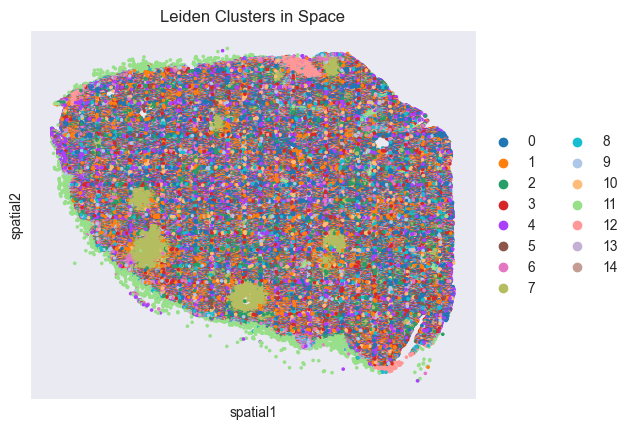


Simplified cluster characterization complete.


In [12]:
# Spatial Visualization of Clusters
print("\n--- Plotting spatial distribution of clusters ---")
if 'spatial' in adata.obsm and 'leiden' in adata.obs.columns:
    spatial_colors = ['leiden']
    # Add annotated types
    if 'cell_type_annotation' in adata.obs.columns:
        spatial_colors.append('cell_type_annotation')

    sc.pl.spatial(adata,
                  color=spatial_colors,
                  spot_size=50, # Adjust spot_size
                  title=['Leiden Clusters in Space', 'Annotated Types in Space'][:len(spatial_colors)])
else:
    print("Skipping spatial plot ('spatial' coords or 'leiden' column missing).")

print("\nSimplified cluster characterization complete.")

# Playing with plotting markers

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_marker_scatter(adata, marker_x, marker_y, save_path=None, point_size=10, alpha=0.6):
    """Scatterplot of two markers from an AnnData object."""
    if marker_x not in adata.var_names or marker_y not in adata.var_names:
        raise ValueError("One or both markers not found in adata.var_names.")

    x = adata[:, marker_x].X.flatten()
    y = adata[:, marker_y].X.flatten()

    plt.figure(figsize=(6, 6))
    plt.scatter(x, y, s=point_size, alpha=alpha)
    plt.xlabel(marker_x)
    plt.ylabel(marker_y)
    plt.title(f"{marker_x} vs {marker_y} Scatter")

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


def plot_marker_contour(adata, marker_x, marker_y, save_path=None, bins=50, levels=5, cmap='viridis'):
    """Contour plot showing density of two markers from an AnnData object."""
    if marker_x not in adata.var_names or marker_y not in adata.var_names:
        raise ValueError("One or both markers not found in adata.var_names.")

    x = adata[:, marker_x].X.flatten()
    y = adata[:, marker_y].X.flatten()

    H, xedges, yedges = np.histogram2d(x, y, bins=bins)
    X, Y = np.meshgrid((xedges[:-1] + xedges[1:])/2, (yedges[:-1] + yedges[1:])/2)
    Z = H.T  # align axes

    plt.figure(figsize=(6, 6))
    plt.contour(X, Y, Z, levels=levels, cmap=cmap)
    plt.xlabel(marker_x)
    plt.ylabel(marker_y)
    plt.title(f"{marker_x} vs {marker_y} Density Contour")

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


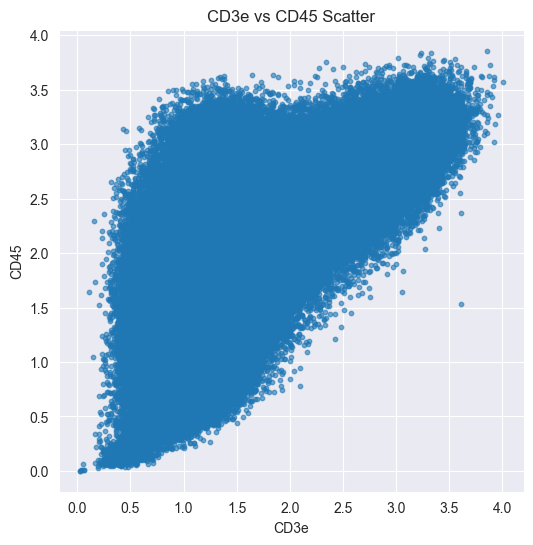

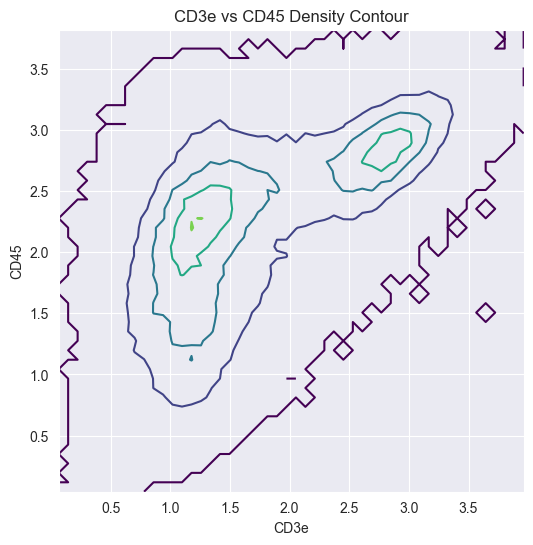

In [37]:
# Scatter
plot_marker_scatter(adata, 'CD3e', 'CD45', save_path="CD3e_vs_CD45_arcsinh_scatter.png")

# Contour
plot_marker_contour(adata, 'CD3e', 'CD45', save_path="CD3e_vs_CD45_arcsinh_contour.png")


## Finished with cluster characterization, now exploring specific markers and clusters

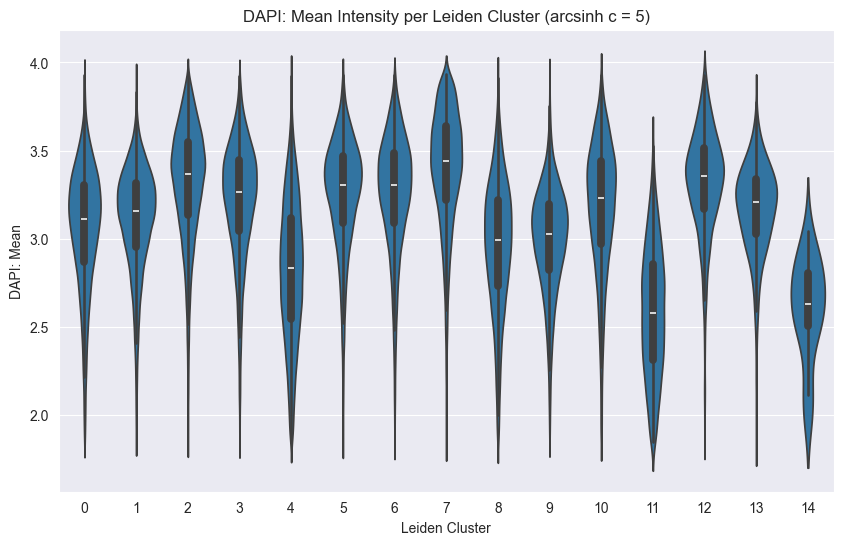

In [13]:
marker = 'DAPI'
if marker in adata.var_names:
    dapi_values = adata[:, marker].X.flatten()
    clusters = adata.obs['leiden']
    df_violin = pd.DataFrame({'DAPI': dapi_values, 'leiden': clusters})

    plt.figure(figsize=(10, 6))
    sns.violinplot(x='leiden', y='DAPI', data=df_violin, inner='box')
    plt.title('DAPI: Mean Intensity per Leiden Cluster (arcsinh c = 5)')
    plt.xlabel('Leiden Cluster')
    plt.ylabel('DAPI: Mean')
    plt.show()
else:
    print(f"{marker} not found in adata.var_names.")

In [ ]:
sc.pl.scatter(adata, x='CD3e', y='CD31', color='leiden', basis=None)


In [ ]:
import scanpy as sc

# Specify clusters to plot
clusters_to_plot = ['2', '0', '12', '1', '8', '14']

# Filter the anndata object for the desired clusters
adata_subset = adata[adata.obs['leiden'].isin(clusters_to_plot)]

# Plot the spatial distribution for the filtered clusters
sc.pl.spatial(adata_subset, color='leiden', spot_size=50, title='Spatial Distribution of Selected Clusters')

In [ ]:
import scanpy as sc

clusters_to_plot = ['2', '0', '12', '1', '8', '14']

for cluster in clusters_to_plot:
    adata_cluster = adata[adata.obs['leiden'] == cluster]
    sc.pl.spatial(adata_cluster,
                  color='leiden',
                  spot_size=50,
                  title=f'Spatial Distribution for Cluster {cluster}')

In [ ]:
sc.pl.violin(adata, ['Area µm^2'], groupby='leiden', rotation=90)
plt.title('Distribution of Cell Area per Leiden Cluster')
plt.show()

In [ ]:

# Create a new AnnData object that excludes cells from cluster '14'.
# The .copy() is important to create a new, independent object.
adata_filtered = adata[adata.obs['leiden'] != '14'].copy()

print(f"Original number of cells: {adata.n_obs}")
print(f"Number of cells after removing cluster 14: {adata_filtered.n_obs}")


# Re-run the analysis pipeline on the filtered data
print("\n--- Re-running analysis on filtered data ---")

# Re-calculate PCA
sc.tl.pca(adata_filtered)

# Re-calculate the neighborhood graph using the same parameters as before
sc.pp.neighbors(adata_filtered, n_neighbors=10, use_rep='X_pca')

# Re-calculate UMAP using the same parameters
sc.tl.umap(adata_filtered, min_dist=0.5, spread=0.3)

# Re-run Leiden clustering to get new cluster assignments
sc.tl.leiden(adata_filtered, resolution=0.5)

print("Re-clustering complete.")


# Visualize the new, re-clustered results
print("\n--- Visualizing re-clustered results ---")
# Plot the new UMAP to see the updated cluster structure
sc.pl.umap(adata_filtered, color='leiden', title='UMAP after removing cluster 14 and re-clustering', legend_loc='on data', size=10)

In [ ]:
# The total number of cells in an AnnData object is stored in the .n_obs attribute.
total_cell_count = adata.n_obs

print(f"The total number of cells in the dataset is: {total_cell_count}")

# print("\nCell counts per sample (example):")
# print(adata.obs['sample_id'].value_counts())

In [ ]:
import scanpy as sc
from sklearn.cluster import DBSCAN
import numpy as np

# Run DBSCAN on spatial coordinates
print("--- Running DBSCAN on spatial coordinates ---")

# Extract spatial coordinates from the AnnData object
spatial_coords = adata.obsm['spatial']

# Set DBSCAN parameters. These may need tuning.
# eps: The maximum distance between two cells to be considered neighbors.
# min_samples: The minimum number of cells required to form a dense cluster.
eps_distance = 30  # Example value in micrometers
min_cells = 10     # Example value, adjust based on expected GC size

# Initialize and run DBSCAN
dbscan = DBSCAN(eps=eps_distance, min_samples=min_cells)
clusters = dbscan.fit_predict(spatial_coords)

# Add the DBSCAN cluster labels to adata.obs
# Cluster label '-1' is assigned to cells considered as noise (not in a dense cluster)
adata.obs['dbscan_cluster'] = [str(c) for c in clusters]

print(f"DBSCAN found {len(np.unique(clusters)) - 1} dense clusters.")
print(f"Cells assigned to noise (cluster -1): {np.sum(clusters == -1)}")


# Visualize DBSCAN clusters on the spatial plot
print("\n--- Visualizing DBSCAN spatial clusters ---")

sc.pl.spatial(
    adata,
    color='dbscan_cluster',
    spot_size=50,
    title=f'DBSCAN Clusters (eps={eps_distance}, min_samples={min_cells})',
    legend_loc='on data' # Places labels on the clusters
)

In [ ]:
import scanpy as sc

# Specify clusters to plot
clusters_to_plot = ['13', '7']

# Filter the anndata object for the desired clusters
adata_subset = adata[adata.obs['leiden'].isin(clusters_to_plot)]

# Plot the spatial distribution for the filtered clusters
sc.pl.spatial(adata_subset, color='leiden', spot_size=50, title='Spatial Distribution of Selected Clusters')

In [ ]:


# Preconditions
assert 'leiden' in adata.obs, "Missing `leiden` in adata.obs"
assert 'Area µm^2' in adata.obs, "Missing `Area µm^2` in adata.obs"
assert 'spatial' in adata.obsm, "Missing `spatial` in adata.obsm"

# Select cluster 6
adata.obs['leiden'] = adata.obs['leiden'].astype(str)
cl = '7'
mask = (adata.obs['leiden'] == cl)
assert mask.any(), f"No cells found in cluster {cl}"

xy = adata.obsm['spatial']
area = adata.obs.loc[mask, 'Area µm^2'].astype(float).values

#  Size scaling using percentiles to avoid outliers dominating point size
p10, p90 = np.percentile(area, [10, 90])
den = (p90 - p10) if p90 > p10 else max(np.std(area, ddof=1), 1e-9)
norm = np.clip((area - p10) / den, 0, 1)
min_size, max_size = 20.0, 200.0
sizes_sel = min_size + norm * (max_size - min_size)

# Plot: background (non‑cluster) dimmed, cluster 6 colored by area and sized by area
bg_mask = ~mask.values if isinstance(mask, pd.Series) else ~mask
plt.figure(figsize=(7, 6))
plt.scatter(xy[bg_mask, 0], xy[bg_mask, 1], c=[0.85, 0.85, 0.85], s=6, alpha=0.08, linewidths=0, rasterized=True)
h = plt.scatter(xy[mask, 0], xy[mask, 1], c=area, cmap='viridis', s=sizes_sel, alpha=0.9, linewidths=0, rasterized=True)

plt.gca().set_aspect('equal', adjustable='box')
plt.gca().invert_yaxis() 
cb = plt.colorbar(h)
cb.set_label('Area µm^2')
plt.title('Spatial: Cluster 7 sized and colored by Area µm^2')
plt.xlabel('X'); plt.ylabel('Y')
plt.tight_layout()
plt.show()

# Summary statistics for cluster 6 areas
a = area
stats = {
    'n': a.size,
    'min': float(np.min(a)),
    'p25': float(np.percentile(a, 25)),
    'median': float(np.median(a)),
    'mean': float(np.mean(a)),
    'p75': float(np.percentile(a, 75)),
    'max': float(np.max(a)),
}
print("Cluster 7 area stats (µm^2):", stats)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Preconditions
assert 'leiden' in adata.obs, "Missing `leiden` in adata.obs"
assert 'Area µm^2' in adata.obs, "Missing `Area µm^2` in adata.obs"
assert 'spatial' in adata.obsm, "Missing `spatial` in adata.obsm"

# Select cluster 7 and filter by area
adata.obs['leiden'] = adata.obs['leiden'].astype(str)
cl = '7'
area_threshold = 80.0
# Added area condition to the mask
mask = (adata.obs['leiden'] == cl) & (adata.obs['Area µm^2'] >= area_threshold)
assert mask.any(), f"No cells found in cluster {cl} with area >= {area_threshold} µm^2"

xy = adata.obsm['spatial']
area = adata.obs.loc[mask, 'Area µm^2'].astype(float).values

# Robust size scaling using percentiles to avoid outliers dominating point size
p10, p90 = np.percentile(area, [10, 90])
den = (p90 - p10) if p90 > p10 else max(np.std(area, ddof=1), 1e-9)
norm = np.clip((area - p10) / den, 0, 1)
min_size, max_size = 20.0, 200.0
sizes_sel = min_size + norm * (max_size - min_size)

# Plot: background (non‑filtered) dimmed, filtered cluster cells colored by area
bg_mask = ~mask.values if isinstance(mask, pd.Series) else ~mask
plt.figure(figsize=(7, 6))
plt.scatter(xy[bg_mask, 0], xy[bg_mask, 1], c=[0.85, 0.85, 0.85], s=6, alpha=0.08, linewidths=0, rasterized=True)
h = plt.scatter(xy[mask, 0], xy[mask, 1], c=area, cmap='viridis', s=sizes_sel, alpha=0.9, linewidths=0, rasterized=True)

plt.gca().set_aspect('equal', adjustable='box')
plt.gca().invert_yaxis()
cb = plt.colorbar(h)
cb.set_label('Area µm^2')

plt.title(f'Spatial: Cluster {cl} (Area >= {area_threshold} µm^2) sized and colored by Area')
plt.xlabel('X'); plt.ylabel('Y')
plt.tight_layout()
plt.show()

# Summary statistics for the filtered areas
a = area
stats = {
    'n': a.size,
    'min': float(np.min(a)),
    'p25': float(np.percentile(a, 25)),
    'median': float(np.median(a)),
    'mean': float(np.mean(a)),
    'p75': float(np.percentile(a, 75)),
    'max': float(np.max(a)),
}
print(f"Cluster {cl} area stats (for cells with Area >= {area_threshold} µm^2):", stats)

In [ ]:
import scanpy as sc

# Major lineage palette (ADJUSTED FOR CONTRAST)
major_palette = {
    'T cells'   : '#2171b5',  # Strong Blue
    'T-Cells'   : '#2171b5',
    'B cells'   : '#4daf4a',  # Vibrant Green
    'B-Cells'   : '#4daf4a',
    'Myeloid'   : '#ff7f00',  # Bright Orange
    'Stromal'   : '#984ea3',  # Distinct Purple
    'Unassigned': '#999999'   # Medium Grey
}

# Fine cell type palette (SIMPLIFIED LABELS)
fine_palette = {
    # B lineage -> shades of green
    'GC B': '#1a9850',                 # Darker Green
    'Memory B': '#66c2a5',             # Teal
    'Follicular/Mature B': '#a6d96a',  # Light Green
    'Activated B': '#d9ef8b',          # Pale Green
    'Pan B': '#4daf4a',                # Match major palette

    # T lineage -> shades of blue/purple
    'Tfh': '#2166ac',                  # Dark Blue
    'CD8 T': '#4393c3',                # Medium Blue
    'Naive-like T': '#92c5de',         # Light Blue
    'Tfr': '#8e44ad',                  # Kept distinct purple
    'CD4 T': '#d1e5f0',                # Pale Blue
    'Memory/Resident T': '#6495ED',    # Cornflower Blue
    'Other T': '#b2abd2',              # Lavender

    # Myeloid/DC -> shades of orange/brown
    'Macrophage': '#d73027',           # Red-Orange
    'Monocyte-like': '#f46d43',        # Bright Orange
    'APC': '#fdae61',                  # Lighter Orange
    'cDC2-like': '#fee090',            # Pale Yellow-Orange
    'cDC1-like': '#b15928',            # Brown

    # Stromal/FDC -> shades of purple/pink
    'FDC/Stromal': '#58508d',          # Dark Purple
    'Lymphatic endothelium': '#bc5090',# Magenta
    'Endothelial': '#ff6361',          # Coral
    'Fibroblast/Stromal': '#ffa600',   # Gold

    'Unassigned': '#999999' # Medium Grey
}


# Map cluster -> major lineage
cluster_to_major = {
    '0': 'Myeloid', '1': 'Myeloid', '2': 'T cells', '3': 'T cells',
    '4': 'Myeloid', '5': 'T cells', '6': 'T cells', '7': 'B cells',
    '8': 'Myeloid', '9': 'Myeloid', '10': 'Myeloid', '11': 'Stromal',
    '12': 'T cells', '13': 'B cells', '14': 'Stromal',
}

# Map cluster -> fine cell type
cluster_to_fine = {
    '0':  'Monocyte-like',
    '1':  'Monocyte-like',
    '2':  'Naive-like T',
    '3':  'CD8 T',
    '4':  'Macrophage',
    '5':  'Tfr',
    '6':  'Tfh',
    '7':  'GC B',  
    '8':  'Macrophage',
    '9':  'Macrophage',
    '10': 'Monocyte-like',
    '11': 'FDC/Stromal',
    '12': 'Tfr',
    '13': 'Memory B', 
    '14': 'Lymphatic endothelium',
}

# Apply mappings to AnnData
adata.obs['celltype_major'] = adata.obs['leiden'].astype(str).map(cluster_to_major).fillna('Unassigned')
adata.obs['celltype_fine']  = adata.obs['leiden'].astype(str).map(cluster_to_fine).fillna('Unassigned')

# Plot major cell types with the new improved palette
sc.pl.spatial(adata, color='celltype_major', title='IHOPE26 LN · Major lineages',
              spot_size=50, palette=major_palette)

# Plot fine cell types with legend outside and the updated palette
sc.pl.spatial(adata, color='celltype_fine',  title='IHOPE26 LN · Finer cell types',
              legend_loc='right margin', spot_size=50, palette=fine_palette)

In [ ]:
# Plot fine cell types with legend outside and the updated palette
sc.pl.spatial(adata, color='celltype_fine',  title='IHOPE26 LN · Finer cell types',
              legend_loc='right margin', spot_size=50, palette=fine_palette)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

#  Define the 'GC_core' based on the fine cell type annotation
# Creates a boolean mask where True corresponds to 'GC B' cells.
adata.obs['GC_core'] = (adata.obs['celltype_fine'] == 'GC B')


xy = adata.obsm['spatial']
mask_core = adata.obs['GC_core'].values

# tuned DBSCAN parameters for GC foci detection
eps_um = 60.0    # neighborhood radius (µm)
min_cells = 100  # minimum cells to call a GC focus

db = DBSCAN(eps=eps_um, min_samples=min_cells).fit(xy[mask_core])
gc_focus_id = np.full(adata.n_obs, -1, dtype=int)
gc_focus_id[mask_core] = db.labels_
adata.obs['gc_focus_id'] = gc_focus_id

sizes = pd.Series(db.labels_[db.labels_>=0]).value_counts().sort_index()
print(f"GC foci detected: {len(sizes)}")
display(sizes.rename('cells_per_focus').to_frame())

# quick map
plt.figure(figsize=(6.8,6))
plt.scatter(xy[~mask_core,0], xy[~mask_core,1], s=2, c='0.85', alpha=0.08, lw=0)
for k in sorted(set(db.labels_) - {-1}):
    sel = (adata.obs['gc_focus_id'].values == k)
    plt.scatter(xy[sel,0], xy[sel,1], s=6, lw=0, label=f'GC {k}')
plt.gca().set_aspect('equal'); plt.gca().invert_yaxis()
plt.title('IHOPE26 LN – GC regions (GC B cells)'); plt.legend(frameon=False, ncol=2); plt.tight_layout(); plt.show()
